### Quiz-2
* 이상치를 해결하시오
    1. 이상치 삭제 후 확인
    2. 이상치 중앙값으로 치환 후 확인
    3. 이상치 평균값으로 치환 후 확인
    4. 이상치 최빈값으로 치환 후 확인(최빈값이 여러개 나올경우 0번째 값으로 진행하세요)

In [93]:
#food.csv의 내용을 불러오세요


,food_a,food_b,food_c
0,20,5,5
1,21,6,5
2,23,11,5
3,22,13,12
4,26,15,10
5,120,16,11
6,35,20,20
7,35,20,20
8,41,21,350
9,42,23,20


In [1]:
import pandas as pd

df = pd.read_csv("../../data_set/2.데이터 클린징/food.csv")

In [2]:
df

,food_a,food_b,food_c
0,20,5,5
1,21,6,5
2,23,11,5
3,22,13,12
4,26,15,10
5,120,16,11
6,35,20,20
7,35,20,20
8,41,21,350
9,42,23,20


### 이상치 확인

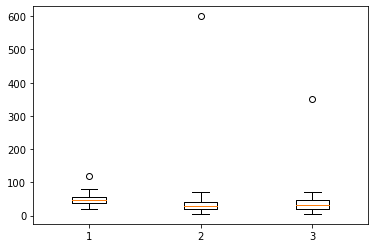

In [80]:
# boxplot를 이용하여 이상치 확인


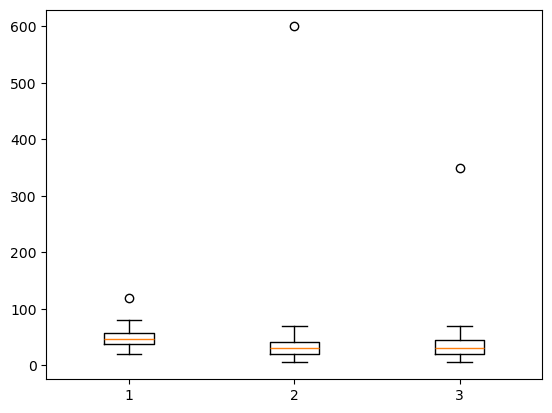

In [7]:
import matplotlib.pyplot as plt

plt.boxplot(df)
plt.show()


In [94]:
# 각 리스트에 최저, 최고 이상치를 food_a, food_b, food_c 순서대로 넣고 아래쪽 코드에서 이상치 확인
lowerfence = []
upperfence = []

#반복문 이용하여 각 리스트에 이상치를 저장하는 code 추가

#################################################

print('\n------------------------')
print(lowerfence,'최저 이상치')
print(upperfence,' 최고 이상치')

food_a food_b food_c 
------------------------
[9.5, -12.25, -18.25] 최저 이상치
[85.5, 73.75, 83.75]  최고 이상치


In [13]:
desc = df.describe()

columns = ['food_a', 'food_b', 'food_c']
lowerfence = []
upperfence = []

for column in columns :
    q1 = desc.loc["25%"][column]
    q3 = desc.loc["75%"][column]
    iqr = q3 - q1
    lowerfence.append(float(q1 - iqr * 1.5))
    upperfence.append(float(q3 + iqr * 1.5))

print(*columns)
print('\n------------------------')
print(lowerfence,'최저 이상치')
print(upperfence,' 최고 이상치')

food_a food_b food_c

------------------------
[9.5, -12.25, -18.25] 최저 이상치
[85.5, 73.75, 83.75]  최고 이상치


In [95]:
# 위에서 만든 이상치 list를 활용하여 각각의 이상치 값을 출력


food_a 이상치
---------------

   food_a  food_b  food_c
5     120      16      11
----------------------------------------------

food_b 이상치
---------------

    food_a  food_b  food_c
26      80     600      70
----------------------------------------------

food_c 이상치
---------------

   food_a  food_b  food_c
8      41      21     350
----------------------------------------------



In [16]:
for idx, column in enumerate(columns) :
    print(column + " 이상치")
    print("---------------")
    print(df[ ( df[column] < lowerfence[idx] ) | ( df[column] > upperfence[idx] ) ])

food_a 이상치
---------------
   food_a  food_b  food_c
5     120      16      11
food_b 이상치
---------------
    food_a  food_b  food_c
26      80     600      70
food_c 이상치
---------------
   food_a  food_b  food_c
8      41      21     350


In [96]:
# 시리즈 값만 확인
dd = df['food_b'][(df['food_b']<lowerfence[1]) | (df['food_b']> upperfence[1])]
print(dd.index[0])
dd.loc[ dd.index[0] ]

26


600

In [17]:
# 시리즈 값만 확인
dd = df['food_b'][(df['food_b']<lowerfence[1]) | (df['food_b']> upperfence[1])]
print(dd.index[0])
dd.loc[ dd.index[0] ]

26


np.int64(600)

### 1. 이상치 삭제

In [98]:
#반복문을 이용하여 저장되어 있는 이상치를 지우세요.
#삭제 후 확인하면 index 5,8,26인덱스 위치가 삭제된것 확인


,food_a,food_b,food_c
0,20,5,5
1,21,6,5
2,23,11,5
3,22,13,12
4,26,15,10
6,35,20,20
7,35,20,20
9,42,23,20
10,43,22,20
11,45,27,21


In [18]:
for column in columns :
    df = df[ ( df[column] >= lowerfence[idx] ) & ( df[column] <= upperfence[idx] ) ]
df

,food_a,food_b,food_c
0,20,5,5
1,21,6,5
2,23,11,5
3,22,13,12
4,26,15,10
6,35,20,20
7,35,20,20
9,42,23,20
10,43,22,20
11,45,27,21


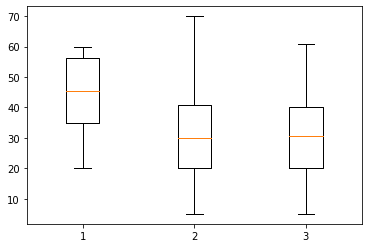

In [99]:
#위에서 이상치 제거 후 boxplot 확인


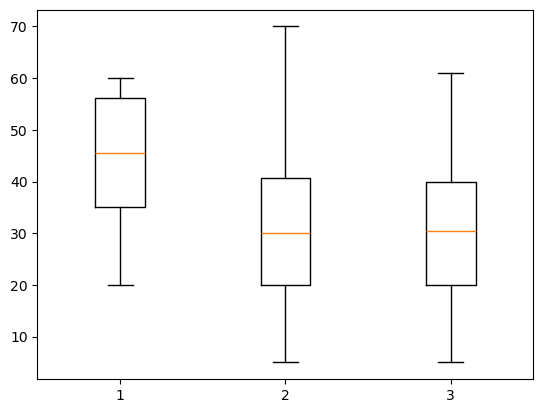

In [19]:
plt.boxplot(df)
plt.show()

### 2.이상치 중앙값으로 치환 후 확인

In [102]:
# food.csv 파일 다시 불러오기


(27, 3)

In [20]:
df = pd.read_csv("../../data_set/2.데이터 클린징/food.csv")

In [100]:
#이전의 이상치 값들이 중앙값으로 치환


#food_a 인덱스 5번째
#food_b 인덱스 26번째
#food_c 인덱스 8번째

,food_a,food_b,food_c
0,20,5,5
1,21,6,5
2,23,11,5
3,22,13,12
4,26,15,10
5,46,16,11
6,35,20,20
7,35,20,20
8,41,21,31
9,42,23,20


In [25]:
for column in columns :
    mask = ( df[column] < lowerfence[idx] ) | ( df[column] > upperfence[idx] )
    median = df[column].median()
    df.loc[mask, column] = median
    
df

,food_a,food_b,food_c
0,20,5,5
1,21,6,5
2,23,11,5
3,22,13,12
4,26,15,10
5,46,16,11
6,35,20,20
7,35,20,20
8,41,21,31
9,42,23,20


### 3. 이상치 평균값으로 치환 후 확인

In [103]:
# food.csv 파일 다시 불러오기


(27, 3)

In [23]:
df = pd.read_csv("../../data_set/2.데이터 클린징/food.csv")
df.shape

(27, 3)

In [101]:
# 평균값으로 치환할 경우 소수점수가 나오면 소수점수는 버림으로 처리

#food_a 인덱스 5번째
#food_b 인덱스 26번째
#food_c 인덱스 8번째

,food_a,food_b,food_c
0,20,5,5
1,21,6,5
2,23,11,5
3,22,13,12
4,26,15,10
5,47,16,11
6,35,20,20
7,35,20,20
8,41,21,42
9,42,23,20


In [26]:
import math

for column in columns :
    mask = ( df[column] < lowerfence[idx] ) | ( df[column] > upperfence[idx] )
    mean = math.floor(float(df[column].mean()))
    # df[column] = df[column].astype('float64')
    df.loc[mask, column] = mean
    
df

,food_a,food_b,food_c
0,20,5,5
1,21,6,5
2,23,11,5
3,22,13,12
4,26,15,10
5,46,16,11
6,35,20,20
7,35,20,20
8,41,21,31
9,42,23,20


### 4.이상치 최빈값으로 치환 후 확인
* 최빈값이 여러개인 경우 0번째 값으로 사용한다

In [104]:
# food.csv 파일 다시 불러오기


(27, 3)

In [27]:
df = pd.read_csv("../../data_set/2.데이터 클린징/food.csv")
df.shape

(27, 3)

In [107]:
# 각 컬럼별 최빈값 출력

#food_a 인덱스 5번째
#food_b 인덱스 26번째
#food_c 인덱스 8번째

food_a 최빈값 
 0    47
dtype: int64
food_b 최빈값 
 0    20
1    27
2    30
3    40
dtype: int64
food_c 최빈값 
 0    20
dtype: int64


In [29]:
for column in columns :
    print(column, "최빈값")
    print(df[column].mode())
    print("===================")

food_a 최빈값
0    47
Name: food_a, dtype: int64
food_b 최빈값
0    20
1    27
2    30
3    40
Name: food_b, dtype: int64
food_c 최빈값
0    20
Name: food_c, dtype: int64


In [90]:
# 각 각의 이상치 값을 최빈값으로 치환


,food_a,food_b,food_c
0,20,5,5
1,21,6,5
2,23,11,5
3,22,13,12
4,26,15,10
5,47,16,11
6,35,20,20
7,35,20,20
8,41,21,20
9,42,23,20


In [30]:
for column in columns :
    mask = ( df[column] < lowerfence[idx] ) | ( df[column] > upperfence[idx] )
    mode = df[column].mode().loc[0]
    df.loc[mask, column] = mode
    
df

,food_a,food_b,food_c
0,20,5,5
1,21,6,5
2,23,11,5
3,22,13,12
4,26,15,10
5,47,16,11
6,35,20,20
7,35,20,20
8,41,21,20
9,42,23,20
